In [5]:
# Ready for tomorrow's session on 11/16/25
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels 

In [6]:
credit_data = pd.read_csv('Datasets/credit_train.csv')
credit_data.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,"445,412",Short Term,709,"1,167,493",8 years,Home Mortgage,Home Improvements,"5,214.74",17.2,NaN,6,1,"228,190","416,746",1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,"262,328",Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,"33,295.98",21.1,8.0,35,0,"229,976","850,784",0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,"99,999,999",Short Term,741,"2,231,892",8 years,Own Home,Debt Consolidation,"29,200.53",14.9,29.0,18,1,"297,996","750,090",0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,"347,666",Long Term,721,"806,949",3 years,Own Home,Debt Consolidation,"8,741.90",12.0,NaN,9,0,"256,329","386,958",0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,"176,220",Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,"20,639.70",6.1,NaN,15,0,"253,460","427,174",0.0,0.0


In [7]:
credit_data.shape

(100000, 19)

In [4]:
# Remove NA and Dupes
credit_data = credit_data.drop_duplicates()
credit_data = credit_data.dropna()
credit_data.shape

(31254, 19)

In [8]:
credit_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Years of Credit History,100000.0,18.199141,7.015324,3.6,13.5,16.9,21.7,70.5
Months since last delinquent,46859.0,34.901321,21.997829,0.0,16.0,32.0,51.0,176.0
Number of Open Accounts,100000.0,11.128530,5.009870,0.0,8.0,10.0,14.0,76.0
Number of Credit Problems,100000.0,0.168310,0.482705,0.0,0.0,0.0,0.0,15.0
Bankruptcies,99796.0,0.117740,0.351424,0.0,0.0,0.0,0.0,7.0
Tax Liens,99990.0,0.029313,0.258182,0.0,0.0,0.0,0.0,15.0


In [9]:
# Monthly data needed to be in a numeric format to be plotted - obj -> float 64
credit_data['MonthlyDebt_clean'] = (
    credit_data['Monthly Debt']
    .str.replace(',', '', regex=False)   # remove commas
    .astype(float)                       # convert to float64
)


In [10]:
# Doing the same with Annual Income - course may have unique configuration to get around these issues.
credit_data['AnnualIncome_clean'] = credit_data['Annual Income'].str.replace(',', '', regex=True).astype(int)


In [12]:
# Doing the same with Current Credit Balance  - course may have unique configuration to get around these issues.
credit_data['CurrentCreditBalance_clean'] = credit_data['Current Credit Balance'].str.replace(',', '', regex=True).astype(int)


<Axes: xlabel='MonthlyDebt_clean', ylabel='Months since last delinquent'>

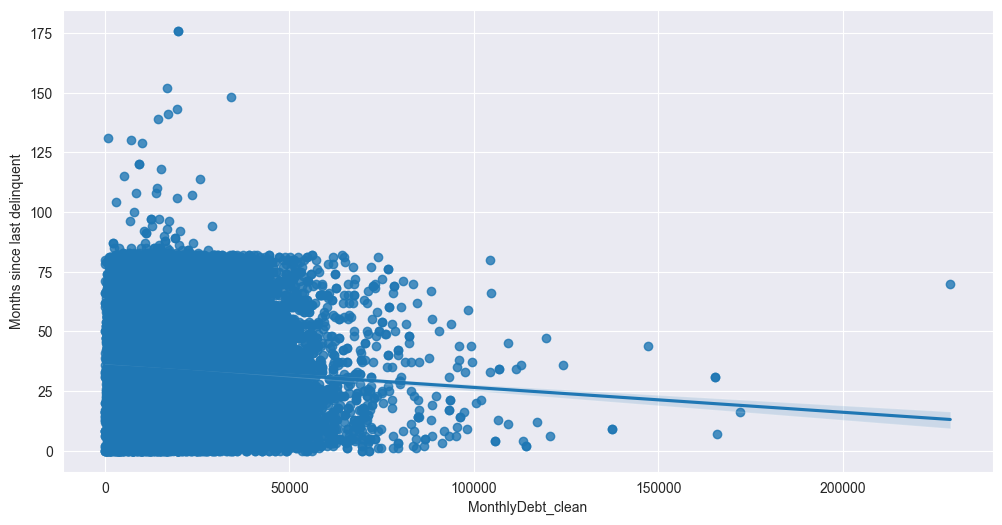

In [13]:
# Utilizing styles
sns.set_style('darkgrid')


# Using access level plt
f,ax = plt.subplots(figsize=(12,6))
sns.regplot(x='MonthlyDebt_clean', y='Months since last delinquent', data=credit_data)

<Axes: xlabel='AnnualIncome_clean', ylabel='MonthlyDebt_clean'>

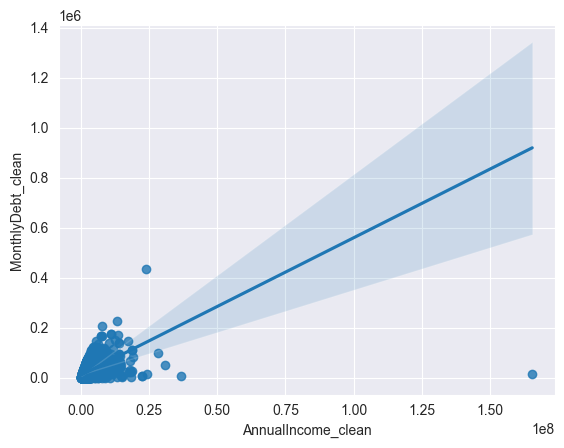

In [14]:
# Using access level plt changing x axis
sns.regplot(x='AnnualIncome_clean', y='MonthlyDebt_clean', data=credit_data)

<Axes: xlabel='AnnualIncome_clean', ylabel='MonthlyDebt_clean'>

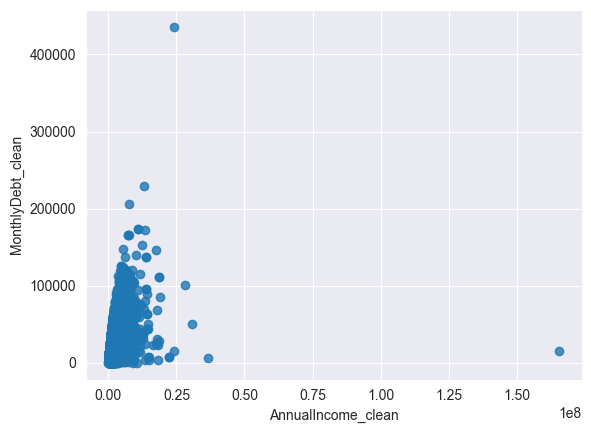

In [15]:
# Using access level plt changing x axis (Trying fit regression param)
# Removes linear portion
sns.regplot(x='AnnualIncome_clean', y='MonthlyDebt_clean',fit_reg=False, data=credit_data)

<Axes: xlabel='AnnualIncome_clean', ylabel='MonthlyDebt_clean'>

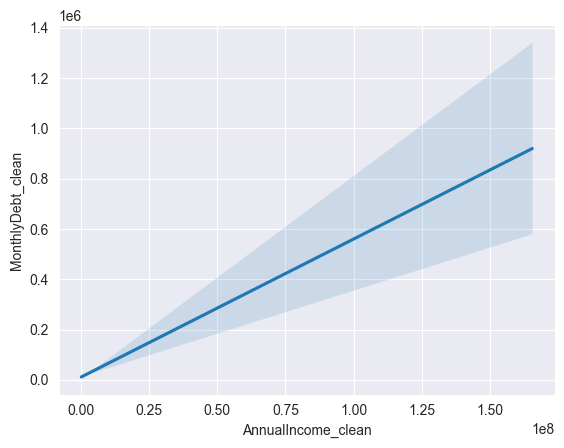

In [16]:
# Using access level plt changing x axis (Trying scatter param)
# Removes scatter portion
sns.regplot(x='AnnualIncome_clean', y='MonthlyDebt_clean',scatter=False, data=credit_data)

<Axes: xlabel='MonthlyDebt_clean', ylabel='CurrentCreditBalance_clean'>

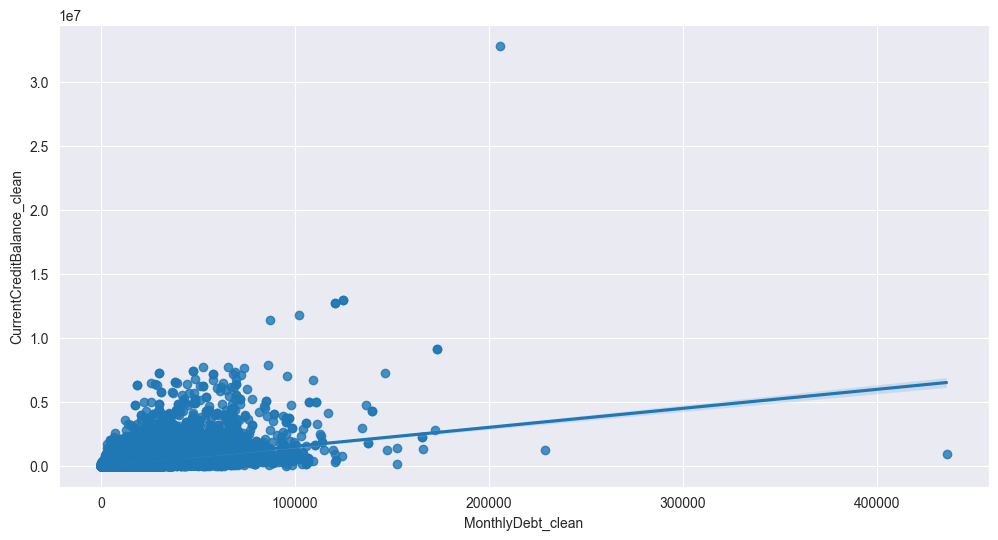

In [17]:
# Using another y axis value
# Using access level plot
f,ax = plt.subplots(figsize=(12,6))
sns.regplot(x=credit_data['MonthlyDebt_clean'], y=credit_data['CurrentCreditBalance_clean'])

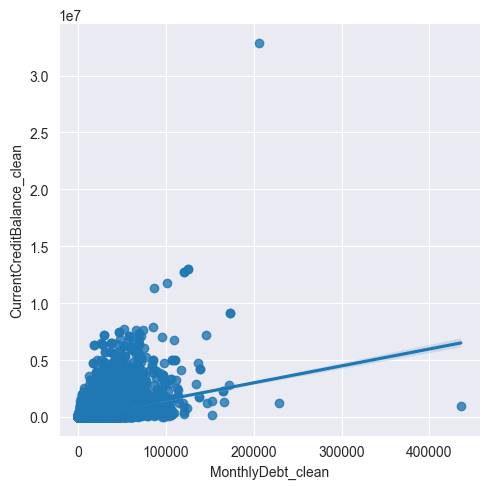

In [18]:
# Using lmplot
sns.lmplot(x='MonthlyDebt_clean', y='CurrentCreditBalance_clean', data=credit_data)

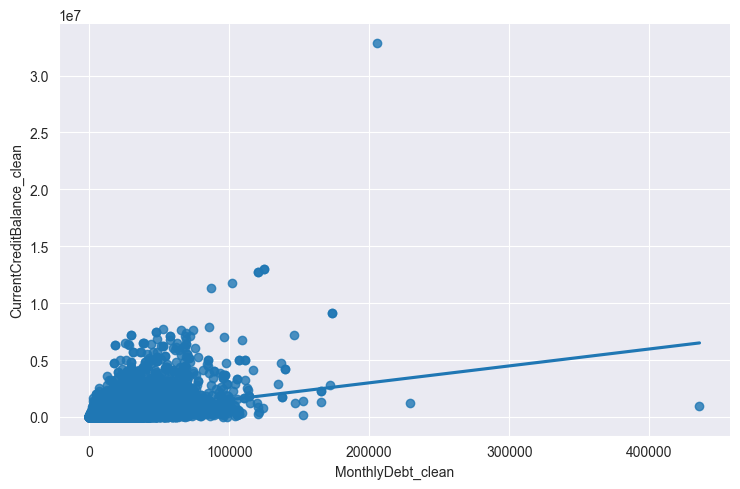

In [19]:
# Using lmplot
# Adding aspect and ci params 
sns.lmplot(x='MonthlyDebt_clean', y='CurrentCreditBalance_clean', data=credit_data, aspect=1.5, ci = None)

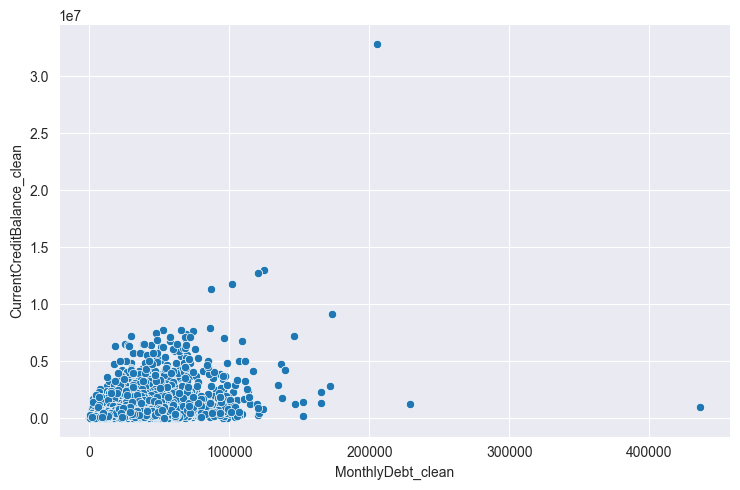

In [20]:
# Using relplot
sns.relplot(x='MonthlyDebt_clean', y='CurrentCreditBalance_clean', data=credit_data, aspect=1.5)

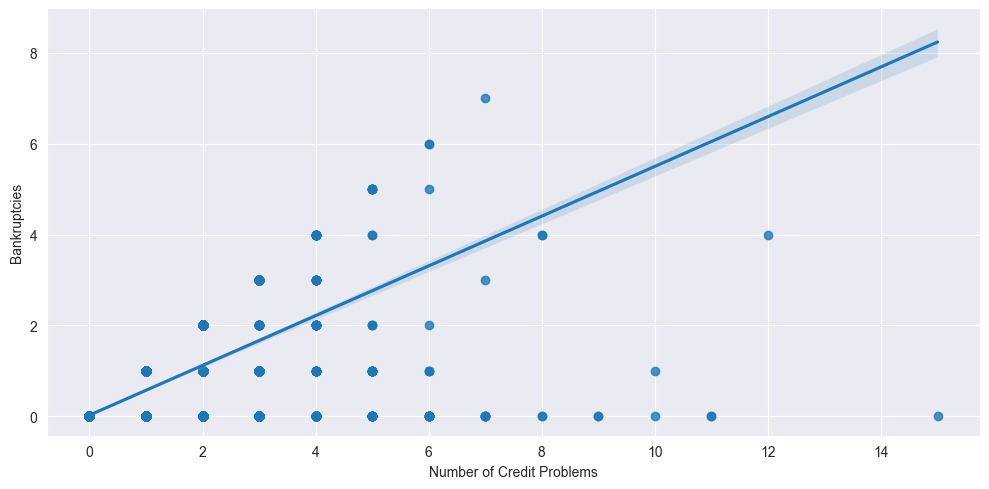

In [21]:
# Using lmplot - using different data 
# Adding aspect  
sns.lmplot(x='Number of Credit Problems', y='Bankruptcies', data=credit_data, aspect=2)

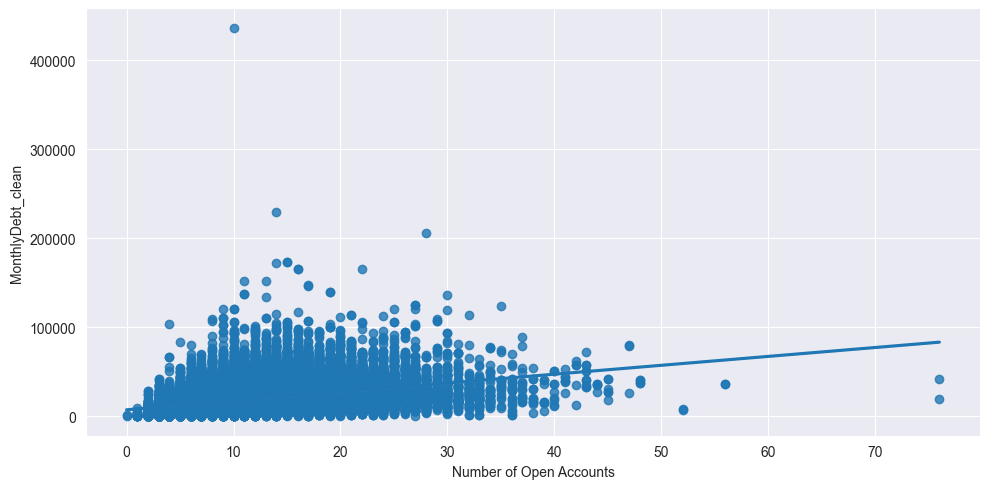

In [30]:
#Picking up on 11/24/25 - With lineplots for regression
sns.lmplot(x='Number of Open Accounts', y='MonthlyDebt_clean', data = credit_data, aspect=2)

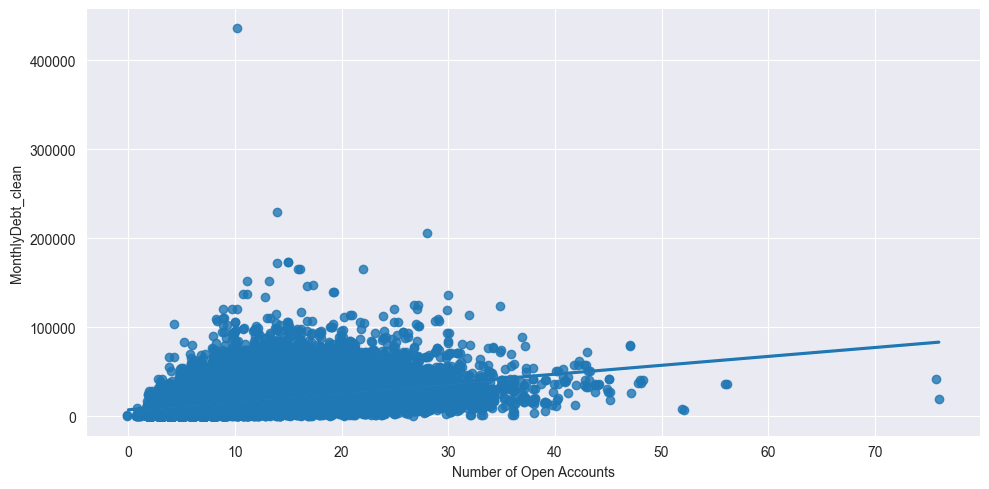

In [31]:
# introducing a new param x_jitter
sns.lmplot(x='Number of Open Accounts', y="MonthlyDebt_clean", data=credit_data, x_jitter=0.3, aspect=2);

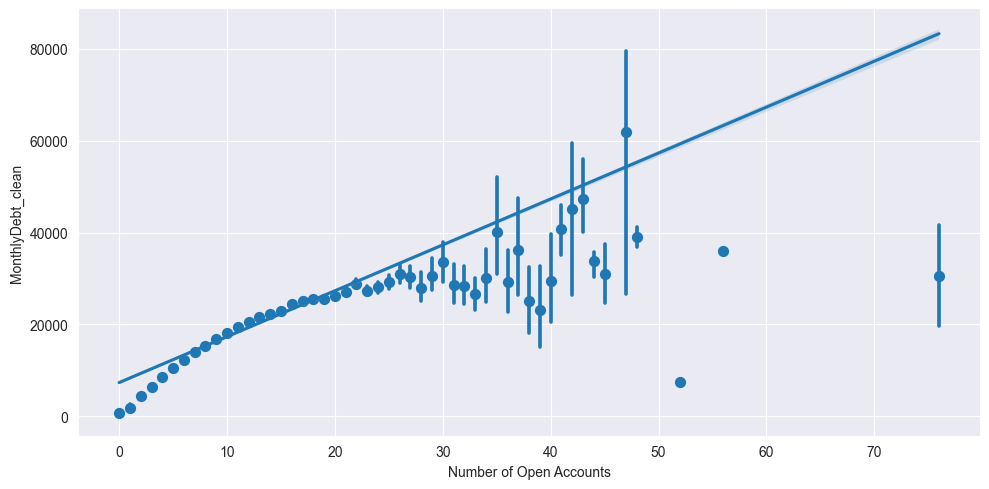

In [33]:
# introducing a new param x_estimator
sns.lmplot(x='Number of Open Accounts', y='MonthlyDebt_clean', data=credit_data, aspect=2, x_estimator = np.mean)

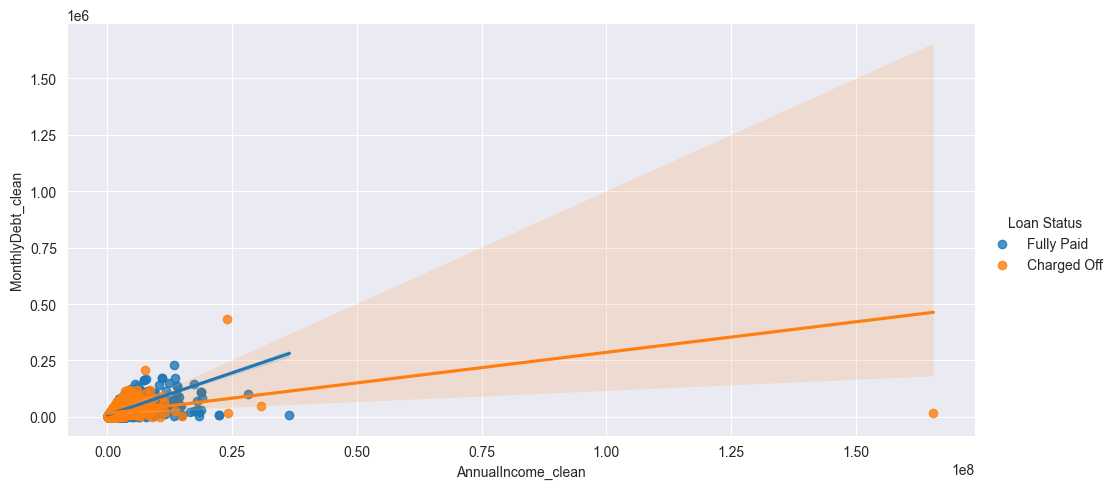

In [39]:
# Hue with lmplot
# Very useful to differentiate data
sns.lmplot(x='AnnualIncome_clean', y='MonthlyDebt_clean', hue= 'Loan Status', data = credit_data, aspect=2)

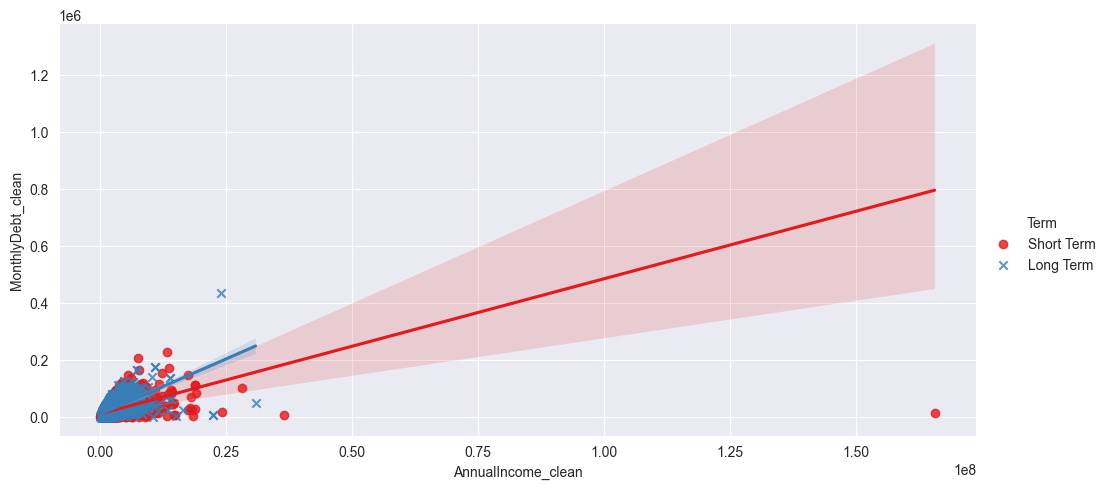

In [40]:
sns.lmplot(x='AnnualIncome_clean', y='MonthlyDebt_clean', hue='Term', markers=['o','x'], palette='Set1', data= credit_data, aspect=2);

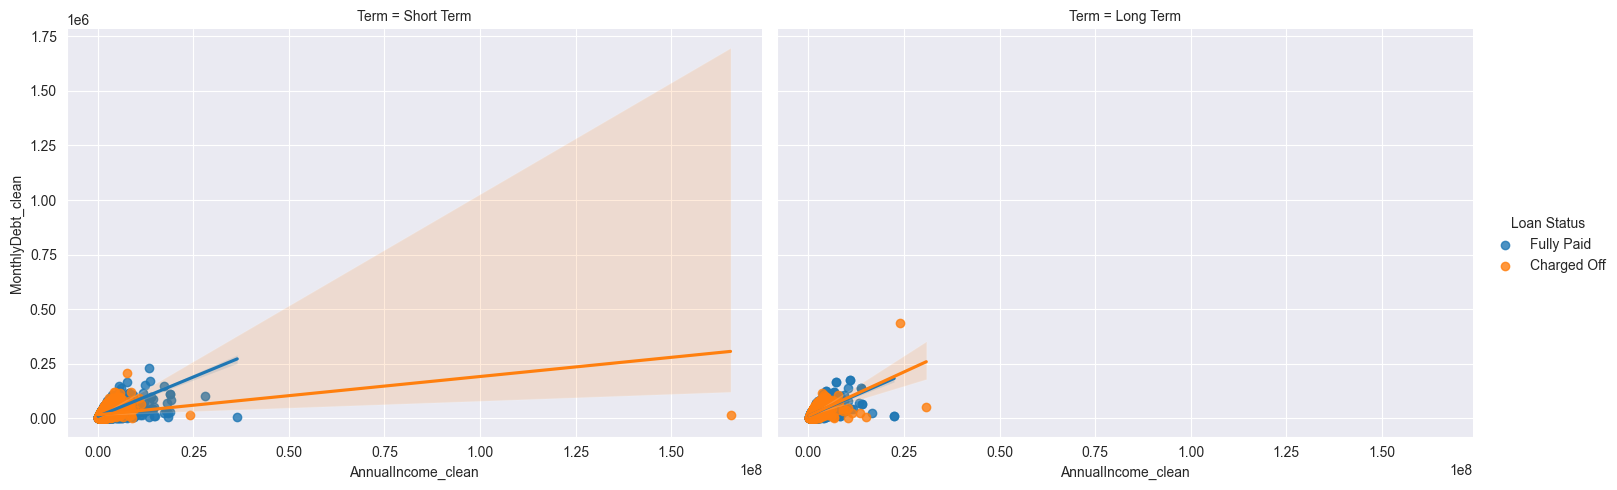

In [41]:
sns.lmplot(x='AnnualIncome_clean', y='MonthlyDebt_clean',hue='Loan Status', col='Term', data= credit_data, aspect=1.5);

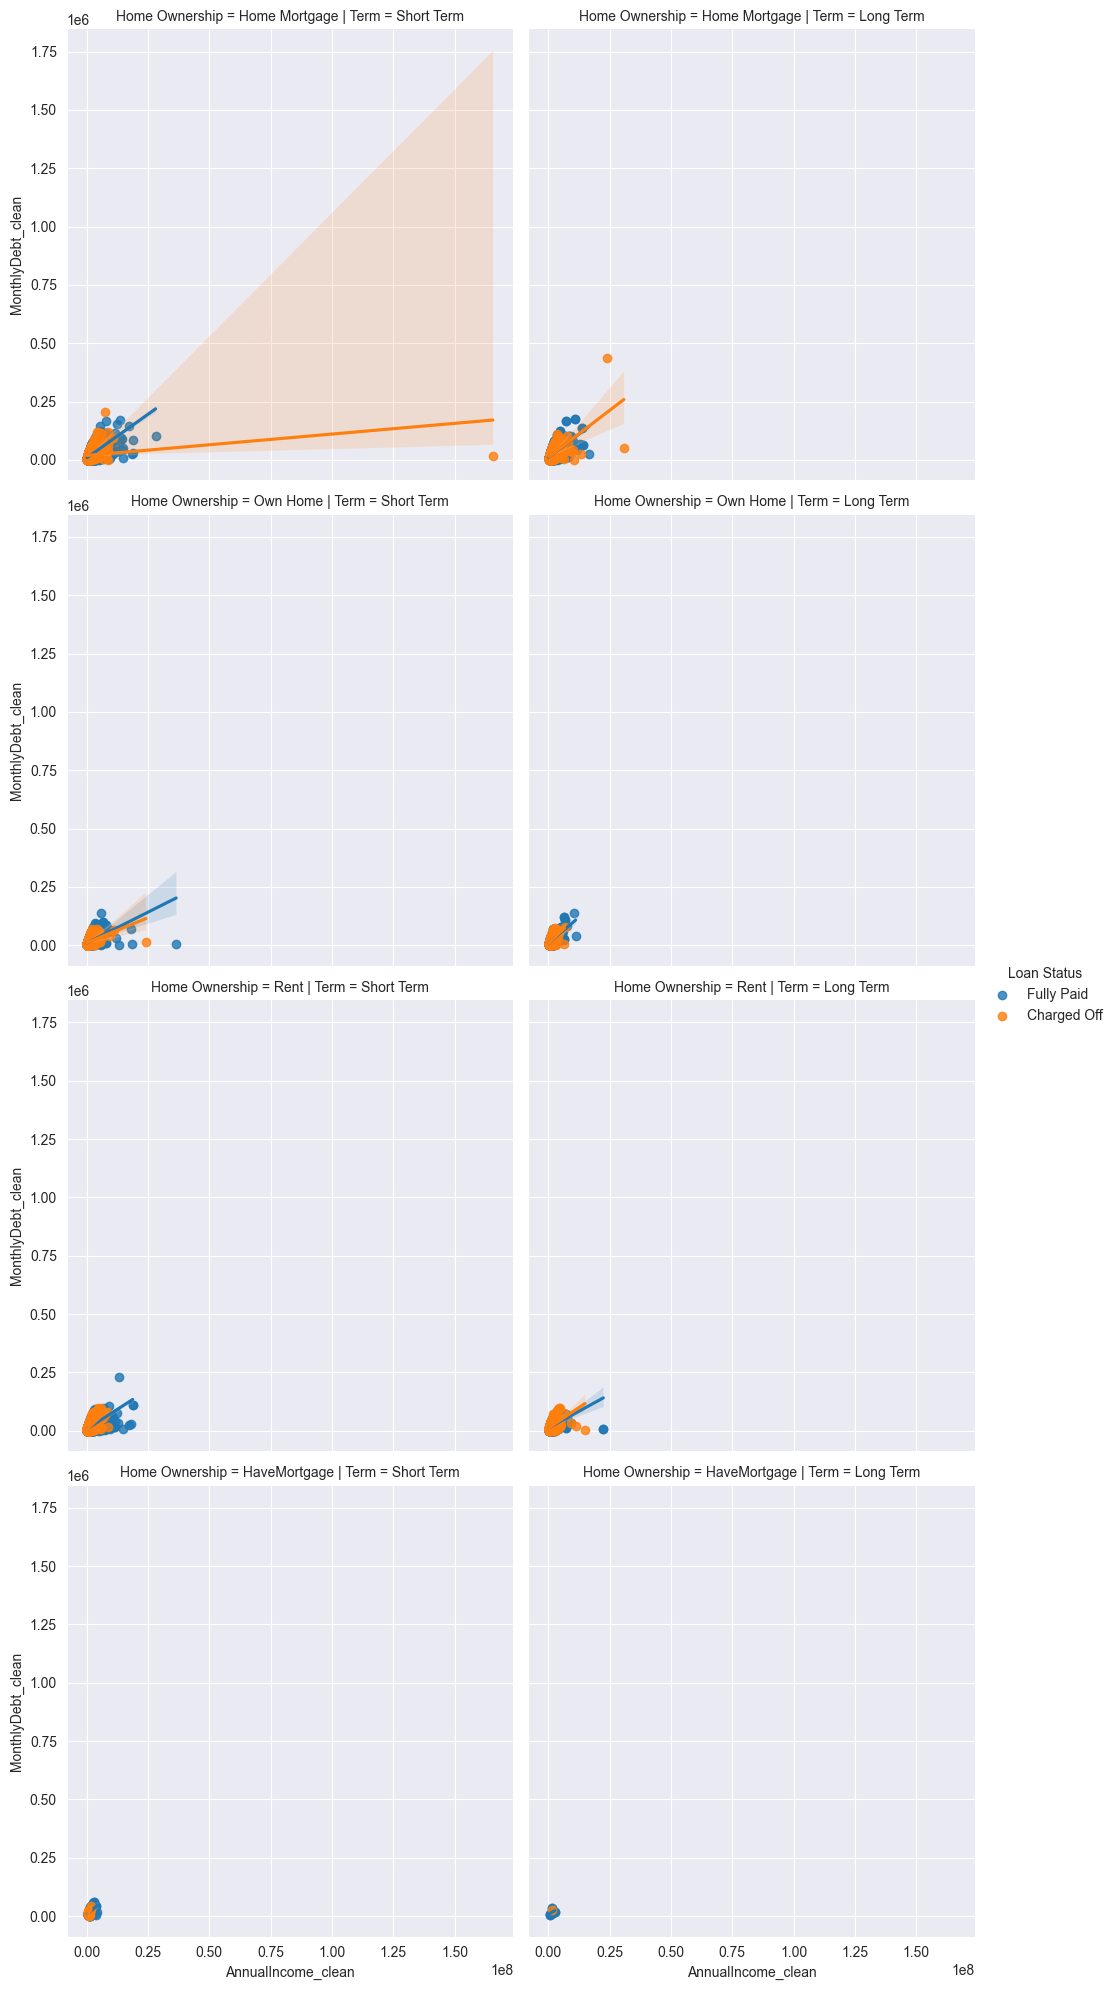

In [42]:
sns.lmplot(x='AnnualIncome_clean', y='MonthlyDebt_clean', hue='Loan Status', col='Term', row='Home Ownership', data= credit_data);